In [1]:
import uproot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import awkward as ak
import numpy as np
import math
import ROOT as root
from array import array

Welcome to JupyROOT 6.26/16


In [2]:
#pull the edep-sim file we have
f = root.TFile.Open("/sdf/home/t/tanaka/MicroProdN4p1_NDComplex_FHC.spill.full.0002459.EDEPSIM_SPILLS.root")
events = f.Get("EDepSimEvents")

# Set the branch address.
event = root.TG4Event()
events.SetBranchAddress("Event",root.AddressOf(event))
keys_file = uproot.open("/sdf/home/t/tanaka/MicroProdN4p1_NDComplex_FHC.spill.full.0002459.EDEPSIM_SPILLS.root")

In [3]:
#literally just to have the convenient display haha
edep_sim_events = keys_file['EDepSimEvents']
edep_sim_events.keys()

['Event',
 'Event/TObject',
 'Event/TObject/fUniqueID',
 'Event/TObject/fBits',
 'Event/RunId',
 'Event/EventId',
 'Event/Primaries',
 'Event/Primaries/Primaries.fUniqueID',
 'Event/Primaries/Primaries.fBits',
 'Event/Primaries/Primaries.Particles',
 'Event/Primaries/Primaries.Informational',
 'Event/Primaries/Primaries.Position',
 'Event/Primaries/Primaries.GeneratorName',
 'Event/Primaries/Primaries.Reaction',
 'Event/Primaries/Primaries.Filename',
 'Event/Primaries/Primaries.InteractionNumber',
 'Event/Primaries/Primaries.CrossSection',
 'Event/Primaries/Primaries.DiffCrossSection',
 'Event/Primaries/Primaries.Weight',
 'Event/Primaries/Primaries.Probability',
 'Event/Trajectories',
 'Event/Trajectories/Trajectories.fUniqueID',
 'Event/Trajectories/Trajectories.fBits',
 'Event/Trajectories/Trajectories.Points',
 'Event/Trajectories/Trajectories.TrackId',
 'Event/Trajectories/Trajectories.ParentId',
 'Event/Trajectories/Trajectories.Name',
 'Event/Trajectories/Trajectories.PDGCode',


In [4]:
# Get the event tree.
# we will want to loop over the events in the file and only be grabbing the trajectories for same events we start with!
n_entries = events.GetEntries()

for i in range(1): #range(n_entries)
    events.GetEntry(i)
    #Let's make sure there are hit segments in the TMS
    tms_hit_segments = event.SegmentDetectors['volTMS']
    if tms_hit_segments.size() > 0:
        #grab the event trajectories vector if we have hits in the TMS, would also be interesting to grab primaries I think, to check for muon. 
        event_primaries = event.Primaries
        event_trajectories = event.Trajectories 

        #can quickly scan the primaries to verify that the interaction at the very least involves a muon.
        for primary in event_primaries:
            print(primary.GetReaction()) #this gives info on the neutrino interaction itself. Pretty cool!
            
            #particles is a vector within the primary
            particles = primary.Particles

            #loop over the particles vector to see what 'primary' particles are in the interaction
            for particle in particles:
                print(particle.GetPDGCode())
                print(particle.GetTrackId())

        
        #now loop over each trajectory in the trajectory vector
        trajs_in_tms_info = [] #stores hit info like |x|y|z|t|trackid|parentid|particle type|
        all_trajs = [] #carries a tuple of trackid and pdgid for all tracks 
        for traj in event_trajectories:
            #each trajectory has a vector of trajectory points. These are tracks of what was traveling through the detector, no edep
            points = traj.Points 
            all_trajs.append(np.array((traj.GetTrackId(),traj.GetPDGCode())))
            #let's make note of the trackids with trajectory positions in the TMS z >= 11185 mm 
            for point in points:
                point_z = point.GetPosition()[2]
                if point_z >= 11185:
                    info_array = np.zeros((1,7))
                    trajs_in_tms_ids.append(traj.GetTrackId())
                    info_array[0][0] = point.GetPosition()[0] #x
                    info_array[0][1] = point.GetPosition()[1] #y
                    info_array[0][2] = point.GetPosition()[2] #z
                    info_array[0][3] = point.GetPosition()[3] #t
                    info_array[0][4] = traj.GetTrackId() #trackID
                    info_array[0][5] = traj.GetParentId() #parentID
                    info_array[0][6] = traj.GetPDGCode() #pdgid of the trajectory that left it!
                    #print(info_array)
                    trajs_in_tms_info.append(info_array)
        print(all_trajs)
        


nu:14;tgt:1000260560;N:2212;q:1(v);proc:Weak[CC],DIS;
13
0
2112
1
2212
2
2212
3
2212
4
2212
5
2212
6
2212
7
2112
8


NameError: name 'trajs_in_tms_ids' is not defined

In [5]:
#sweeps over the trajectories and grabs information for ones which leave trajectory points in the TMS. 
def TrajectorySweeper(events, event_number):
    events.GetEntry(event_number)
    #Let's make sure there are hit segments in the TMS
    tms_hit_segments = event.SegmentDetectors['volTMS']
    if tms_hit_segments.size() > 0:
        #grab the event trajectories vector if we have hits in the TMS, would also be interesting to grab primaries I think, to check for muon. 
        event_primaries = event.Primaries
        event_trajectories = event.Trajectories 
        
        #now loop over each trajectory in the trajectory vector
        trajs_in_tms_info = [] #stores hit info like |x|y|z|t|trackid|parentid|particle type|
        trajs_elsewhere = []
        all_trajs = [] #carries an array of trackid and pdgid for all tracks 
        for traj in event_trajectories:
            #each trajectory has a vector of trajectory points. These are tracks of what was traveling through the detector, no edep
            points = traj.Points 
            all_trajs.append(np.array((traj.GetTrackId(),traj.GetPDGCode())))
            #let's make note of the trackids with trajectory positions in the TMS z >= 11185 mm 
            for point in points:
                point_z = point.GetPosition()[2]

                #fill TMS specifically
                if point_z >= 11185 and point_z <= 18535:
                    info_array = np.zeros((1,7))
                    info_array[0][0] = point.GetPosition()[0] #x
                    info_array[0][1] = point.GetPosition()[1] #y
                    info_array[0][2] = point.GetPosition()[2] #z
                    info_array[0][3] = point.GetPosition()[3] #t
                    info_array[0][4] = traj.GetTrackId() #trackID
                    info_array[0][5] = traj.GetParentId() #parentID
                    info_array[0][6] = traj.GetPDGCode() #pdgid of the trajectory that left it!
                    #print(info_array)
                    trajs_in_tms_info.append(info_array)

                #all other points (largely NDLar)
                if point_z < 11185:
                    info_array = np.zeros((1,7))
                    info_array[0][0] = point.GetPosition()[0] #x
                    info_array[0][1] = point.GetPosition()[1] #y
                    info_array[0][2] = point.GetPosition()[2] #z
                    info_array[0][3] = point.GetPosition()[3] #t
                    info_array[0][4] = traj.GetTrackId() #trackID
                    info_array[0][5] = traj.GetParentId() #parentID
                    info_array[0][6] = traj.GetPDGCode() #pdgid of the trajectory that left it!
                    #print(info_array)
                    trajs_elsewhere.append(info_array)
                    

        tms_info_stack = np.vstack(trajs_in_tms_info)
        
        if len(trajs_elsewhere) > 0:
            ndlar_info_stack = np.vstack(trajs_elsewhere)

        else:
             ndlar_info_stack = None  
            
        all_trajs_stack = np.vstack(all_trajs)
        return((all_trajs_stack, tms_info_stack, ndlar_info_stack))#trajs_in_tms_info))

    else:
        #print(f"No energy deposition in TMS for event {event_number}")
        return((None,None,None))
        
def hitcolor(pdgid):
    c = 'black' # black track by default
    if pdgid == 2212:
        c = 'red' # proton == red
    if pdgid == 2112:
        c = 'green' # neutron == green
    if pdgid == 211:
        c = 'magenta' # pi+ == magenta
    if pdgid == -211:
        c = 'cyan' # pi- == cyan
    if pdgid == 22:
        c = 'gold' # photon == gold
    if pdgid == 13:
        c = 'purple'
    if pdgid == -13:
        c = 'lightcoral'
    """
    if pdgid == 130:
        c = 'orange' # K-long == orange
    if pdgid == 310:
        c = 'darkred' # K-short == dark red
    if pdgid == 321:
        c = 'violet' # K+ == violet
    if pdgid == -321:
        c = 'powderblue' # K- == powder blue

    """
    if pdgid == 11:
        c = 'blue' # electron == blue
    return c    

In [6]:
#weird data storage format (stupid and inefficient I know!) - list event_tms_trajectory_info
# inside the list are lists with two entries, none none if no hits in the TMS, and then full_trajs and tms_trajpoint_info if entries
# better yet, could give it a list of indexes to scan over and produced vertices for!
events.GetEntries()
event_trajectory_info = []
for i in range(500):
    #run the trajectory sweeper
    package = []
    full_trajs , tms_trajpoint_info, ndlar_trajpoint_info = TrajectorySweeper(events, i)
    package.append(full_trajs)
    package.append(tms_trajpoint_info)
    package.append(ndlar_trajpoint_info)
    event_trajectory_info.append(package)
    

data = np.load('../hitwise_detector_sim_0002459.npz')
hit_array = data['second']

FileNotFoundError: [Errno 2] No such file or directory: '../hitwise_detector_sim_0002459.npz'

In [8]:
#grab the lar in case.. not sure if these are even saved properly
event_number_example = 0
event_ = event_trajectory_info[event_number_example]

tms_trajpoint_xs = event_[1][:,0]
tms_trajpoint_zs = event_[1][:,2]
tms_trajpoint_pdgids = event_[1][:,6]
tms_colors = []
for pid in tms_trajpoint_pdgids:
    tms_colors.append(hitcolor(pid))

#now grab just the muon trajectory points (to make sure they are not hidden)

mu_subarray = event_[1][event_[1][:,6] == (13 or -13)]

mu_trajpoint_xs = mu_subarray[:,0]
mu_trajpoint_zs = mu_subarray[:,2]
mu_trajpoint_pdgids = mu_subarray[:,6]
mu_colors = []
for pid in mu_trajpoint_pdgids:
    mu_colors.append(hitcolor(pid))


lar_event = event_trajectory_info[6]

lar_trajpoint_xs = []
lar_trajpoint_zs = []
lar_trajpoint_pdgids = []
lar_colors = []
if event_[2] != None:
    lar_trajpoint_xs = event_[2][:,0]
    lar_trajpoint_zs = event_[2][:,2]
    lar_trajpoint_pdgids = event_[2][:,6]
    lar_colors = []
    for pid in lar_trajpoint_pdgids:
        lar_colors.append(hitcolor(pid))

reco_hit_xs = []
reco_hit_zs = []
reco_hit_PEs = []
for hit in hit_array:
    if (hit[0] == neutrino_number_selected):
        reco_hit_xs.append(hit[2])
        reco_hit_zs.append(hit[4])
        reco_hit_PEs.append(hit[6])


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Text(0.5, 0, 'Detector z (mm)')

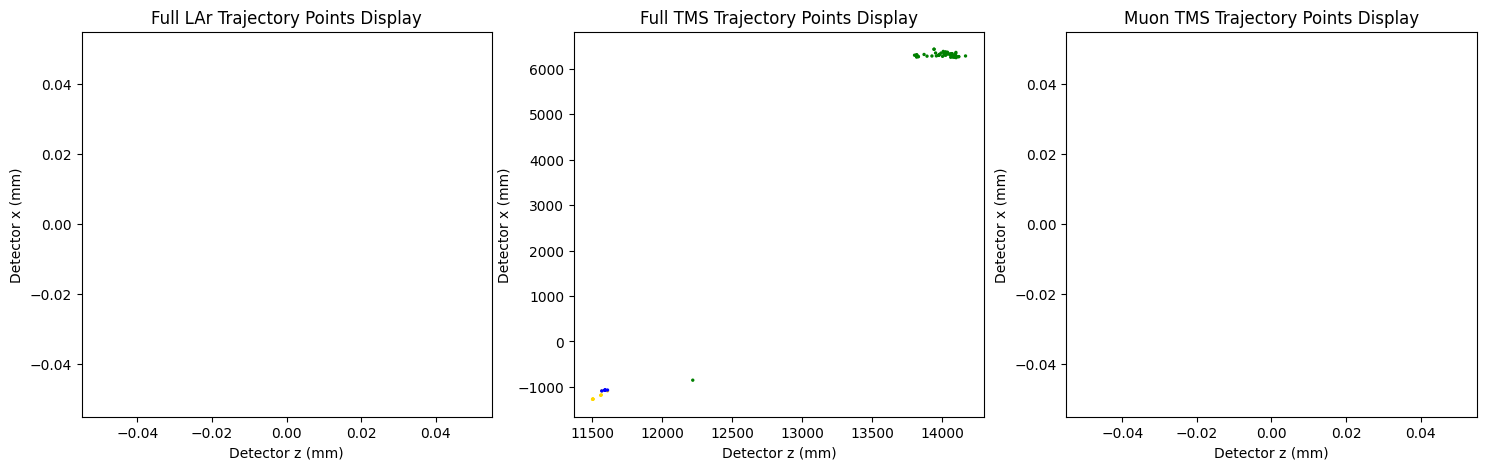

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(lar_trajpoint_zs, lar_trajpoint_xs, c = lar_colors, s = 2)
axes[0].set_title("Full LAr Trajectory Points Display")
axes[0].set_ylabel("Detector x (mm)")
axes[0].set_xlabel("Detector z (mm)")

axes[1].scatter(tms_trajpoint_zs, tms_trajpoint_xs, c = tms_colors, s = 2)
axes[1].set_title("Full TMS Trajectory Points Display")
axes[1].set_ylabel("Detector x (mm)")
axes[1].set_xlabel("Detector z (mm)")

axes[2].scatter(mu_trajpoint_zs, mu_trajpoint_xs, c = mu_colors, s = 2)
axes[2].set_title("Muon TMS Trajectory Points Display")
axes[2].set_ylabel("Detector x (mm)")
axes[2].set_xlabel("Detector z (mm)")


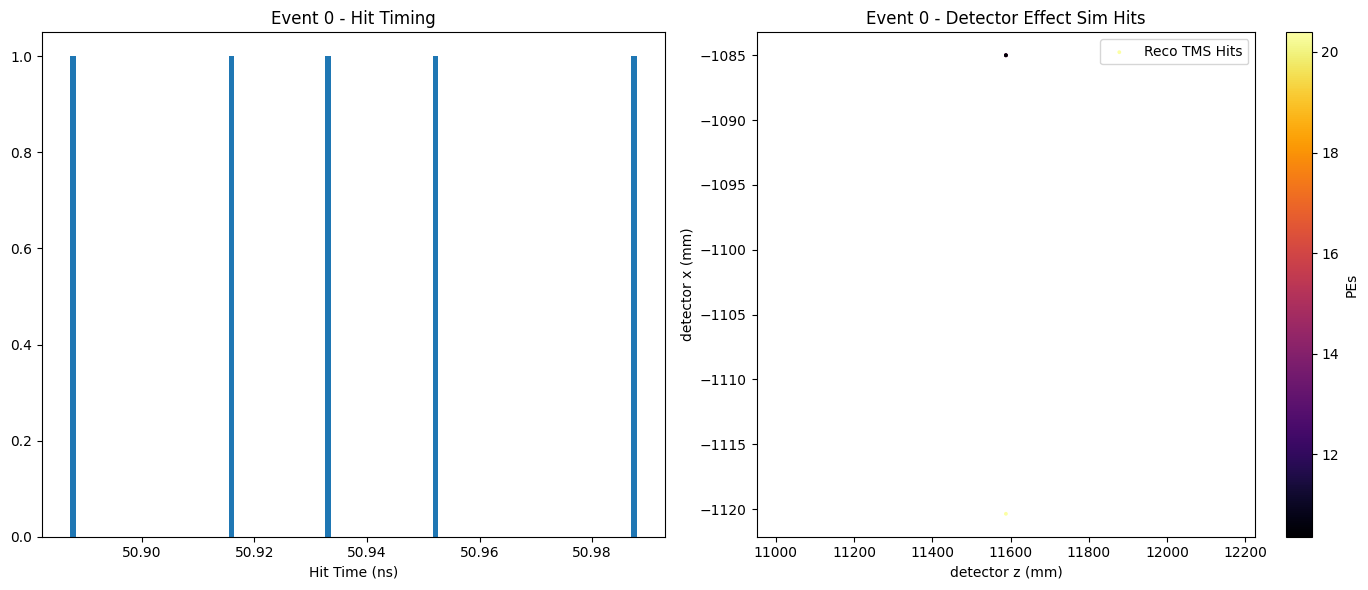

In [10]:
#Let's try and replicate some plots, to show successful data transfer - looks ok!

# Reco hit data
reco_hit_xs = []
reco_hit_zs = []
reco_hit_PEs = []
reco_hit_Ts = []

for hit in hit_array:
    if (hit[0] == event_number_example):
        reco_hit_xs.append(hit[2])
        reco_hit_zs.append(hit[4])
        reco_hit_Ts.append(hit[5])
        reco_hit_PEs.append(hit[6])

#event_neutrino = [vtx for vtx in neutrino_vertices if vtx[0] == event_number_example]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot reco hits
sc2 = ax2.scatter(reco_hit_zs, reco_hit_xs, s=3, c=reco_hit_PEs, cmap='inferno', label='Reco TMS Hits')
#ax2.scatter(event_neutrino[0][3], event_neutrino[0][1], s=35, c='blue', marker='*', label='True Neutrino Vertex')
ax2.set_xlabel("detector z (mm)")
ax2.set_ylabel("detector x (mm)")
ax2.set_title(f"Event {event_number_example} - Detector Effect Sim Hits")
ax2.legend()
fig.colorbar(sc2, ax=ax2, label='PEs')

# Plot truth hits
sc1 = ax1.hist(reco_hit_Ts, bins=100)
ax1.set_xlabel("Hit Time (ns)")
ax1.set_title(f"Event {event_number_example} - Hit Timing")

plt.tight_layout()
plt.show()
